In [ ]:
import pandas_datareader as web
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import scipy.optimize as sco
import seaborn as sns
import statsmodels.api as sm

In [ ]:
n_portfolios = 10**5
n_days = 252
start_date = '2014-01-01'
end_date = '2025-04-11'
#Extracting list of S&P 500 companies from Wikipedia
sp = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',header=0)[0]
#Again removing white space in column names and making all lower case letters
sp.columns= sp.columns.str.replace(' ','_').str.lower()

communication = sp[sp['gics_sector'] == 'Communication Services']

#Extract tickers from the list
tickers = communication['symbol'].tolist()
tickers = [s.replace('.','-') for s in tickers]
n_tickers = len(tickers)
#Download data from Yahoo Finance
!pip install --upgrade yfinance
data = yf.download(tickers, start=start_date, end=end_date)
data_close = data['Close']

percentage_null = data_close.isnull().sum() / len(data_close)
missing = percentage_null[percentage_null > 0.10].index
data_close.drop(missing, axis=1, inplace=True)



YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  23 of 23 completed
<ipython-input-2-6cc24bcf434d>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_close.drop(missing, axis=1, inplace=True)


In [ ]:
monthly_returns = data_close.resample('M').last().pct_change().dropna()

# Download S&P 500 index data
sp500 = yf.download("^GSPC", start=start_date, end=end_date)["Close"]
sp500_monthly_returns = sp500.resample('M').last().pct_change().dropna()

# Merge stock returns with S&P 500 returns
ret = pd.concat([monthly_returns, sp500_monthly_returns], axis=1)
ret.columns = list(monthly_returns.columns) + ["S&P 500"]

<ipython-input-3-c82a97983891>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = data_close.resample('M').last().pct_change().dropna()
[*********************100%***********************]  1 of 1 completed
<ipython-input-3-c82a97983891>:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sp500_monthly_returns = sp500.resample('M').last().pct_change().dropna()


In [ ]:
data_close

Ticker,CHTR,CMCSA,DIS,EA,GOOG,GOOGL,IPG,LYV,META,MTCH,...,NWS,NWSA,OMC,PARA,T,TKO,TMUS,TTWO,VZ,WBD
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-02,134.759995,20.102926,69.335960,22.271576,27.593388,27.723312,11.887257,20.059999,54.453362,18.243618,...,15.812984,15.817218,51.416904,50.921909,11.457993,13.190123,32.632866,17.530001,27.434021,45.528870
2014-01-03,133.369995,19.954449,69.190506,22.125252,27.392099,27.521076,11.900767,20.340000,54.304062,18.375212,...,15.671563,15.702661,51.264034,50.833370,11.408818,13.099502,31.566948,17.629999,27.109287,45.263157
2014-01-06,135.000000,19.934916,68.926880,21.978922,27.697504,27.827915,11.731912,20.500000,56.931683,18.587379,...,15.512459,15.491176,50.027248,50.728695,11.461270,12.753475,32.740437,17.600000,27.260456,44.695965
2014-01-07,138.080002,20.642126,69.399612,22.534977,28.231462,28.364393,11.819715,20.830000,57.648304,18.984854,...,15.309164,15.332564,50.548378,51.026577,11.457993,13.033590,32.486179,18.110001,27.601988,44.425140
2014-01-08,136.089996,20.610868,68.381432,22.739841,28.290215,28.423418,11.833225,20.809999,57.956848,18.888172,...,15.238451,15.235631,49.686794,50.511337,11.424308,13.363136,32.574196,17.799999,27.449179,43.234543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-04,338.290009,33.380001,83.529999,135.339996,147.740005,145.600006,23.700001,120.839996,504.730011,28.740000,...,27.700001,24.580000,72.589996,11.070000,26.360214,139.580002,248.110001,194.580002,42.349785,8.070000
2025-04-07,332.890015,33.470001,83.300003,134.619995,149.240005,146.750000,23.280001,119.230003,516.250000,27.850000,...,27.410000,24.080000,71.550003,10.860000,26.548220,141.179993,246.669998,197.529999,41.906902,8.090000
2025-04-08,321.679993,32.840000,81.720001,132.529999,146.580002,144.699997,22.920000,118.809998,510.450012,27.030001,...,27.540001,23.969999,70.370003,10.650000,26.112839,138.960007,246.300003,196.250000,41.503380,7.690000


In [ ]:
import matplotlib.pyplot as plt

# Initialize FRED API
rf = web.DataReader('TB3MS', 'fred',start='1950-01-01',end='2025-02-18')
rf = (1 + (rf / 100)) ** (1 / 12) - 1
# Convert to monthly and merge with returns
tbill_monthly = rf.resample('M').last()
ret_with_tbill = pd.merge(ret,tbill_monthly,how='inner', left_index=True, right_index=True).dropna()


<ipython-input-5-1d61646c704b>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tbill_monthly = rf.resample('M').last()


In [ ]:
excess_ret = ret_with_tbill.sub(ret_with_tbill['TB3MS'], axis=0).drop(columns=['TB3MS'])
annual_sharpe = excess_ret.groupby(excess_ret.index.year).agg('mean')/excess_ret.groupby(excess_ret.index.year).agg('std')
sharpe_ratio = annual_sharpe.agg('mean')
annual_sharpe

,CHTR,CMCSA,DIS,EA,GOOG,GOOGL,IPG,LYV,META,MTCH,...,NWSA,OMC,PARA,T,TKO,TMUS,TTWO,VZ,WBD,S&P 500
2014,0.324395,0.263115,0.695761,0.619097,-0.228964,-0.214756,0.507357,0.304699,0.350317,-0.189347,...,0.000585,0.203947,-0.030859,0.153036,-0.175580,-0.107196,0.610663,0.032772,-0.176247,0.681177
2015,0.132079,0.017557,0.166592,0.521948,0.446378,0.462874,0.168747,-0.031759,0.465124,-0.170310,...,-0.089885,0.032988,-0.091935,0.224794,0.294761,0.470699,0.236738,0.081939,-0.149560,0.001284
2016,0.668987,0.411124,0.027120,0.168017,0.045752,0.047996,0.074638,0.120962,0.167381,0.252489,...,-0.066306,0.277938,0.530456,0.437642,0.096620,0.719251,0.487752,0.300311,0.060006,0.262969
2017,0.197896,0.266356,0.087653,0.331194,0.683865,0.629796,-0.167428,0.883165,0.745348,0.623590,...,0.524064,-0.212424,-0.095645,-0.023022,0.890436,0.175584,0.860335,0.073021,-0.196743,1.261079
2018,-0.129580,-0.120645,0.051276,-0.155936,-0.007220,-0.002344,0.084089,0.174793,-0.309866,0.247258,...,-0.480150,0.054996,-0.276049,-0.505179,0.524156,0.000902,-0.011113,0.151676,0.109723,-0.136396
2019,0.816448,0.594059,0.294321,0.382204,0.415643,0.398575,0.190801,0.511595,0.409976,0.551434,...,0.260915,0.221106,-0.000841,0.884762,-0.098171,0.372705,0.202345,0.291743,0.251706,0.542749
2020,0.356305,0.199044,0.199977,0.354380,0.291152,0.291676,0.101990,0.083556,0.270590,0.508755,...,0.201462,-0.093552,0.078367,-0.261118,-0.065484,0.592452,0.500409,0.013618,0.015856,0.198751
2021,0.011210,-0.018293,-0.156971,-0.120036,0.647102,0.685960,0.673710,0.391864,0.283826,-0.056705,...,0.266741,0.280555,-0.010044,-0.066167,0.078757,-0.180254,-0.137519,-0.196165,-0.049968,0.641444
2022,-0.315806,-0.236292,-0.401549,-0.050952,-0.501665,-0.506372,-0.044602,-0.451166,-0.430287,-0.684242,...,-0.154410,0.159534,-0.202905,0.079858,0.318461,0.222087,-0.467914,-0.286824,-0.415887,-0.265031
2023,0.126319,0.288104,0.037064,0.113875,0.473809,0.468764,-0.004323,0.260627,1.058874,-0.022318,...,0.329581,0.083499,0.022112,-0.062649,0.178207,0.216263,0.480666,0.001972,0.131668,0.351312


In [ ]:
sharpe_ratio = sharpe_ratio.drop("S&P 500")
top_stocks = sharpe_ratio.nlargest(10)
top_stocks
companies = top_stocks.index.to_list()

In [ ]:
top_stocks

,0
PARA,1.122174
NWSA,0.648934
TMUS,0.360977
NFLX,0.333657
META,0.328159
TTWO,0.303460
LYV,0.259281
TKO,0.252745
CHTR,0.250024
T,0.245237


In [ ]:
companies

['PARA', 'NWSA', 'TMUS', 'NFLX', 'META', 'TTWO', 'LYV', 'TKO', 'CHTR', 'T']

In [ ]:
n_portfolios = 10**5
n_days = 252
returns = yf.download(companies, start=start_date, end=end_date)['Close'].pct_change().dropna()
avg_returns = returns.mean()*n_days
cov_matrix = returns.cov()*n_days
n_tickers = len(companies)

[*********************100%***********************]  10 of 10 completed


In [ ]:
returns

Ticker,CHTR,LYV,META,NFLX,NWSA,PARA,T,TKO,TMUS,TTWO,portfolio_returns,portfolio_returns1,portfolio_returns2
Date,,,,,,,,,,,,,
2014-01-03,-0.010315,0.013958,-0.002742,0.000772,-0.007243,-0.001739,-0.004292,-0.006870,-0.032664,0.005704,0.001769,-0.004543,-0.003969
2014-01-06,0.012222,0.007866,0.048387,-0.009722,-0.013468,-0.002059,0.004598,-0.026415,0.037175,-0.001702,0.009834,0.005688,0.006065
2014-01-07,0.022815,0.016098,0.012587,-0.055817,-0.010239,0.005872,-0.000286,0.021964,-0.007766,0.028977,0.012166,0.003421,0.004216
2014-01-08,-0.014412,-0.000960,0.005352,0.004389,-0.006322,-0.010097,-0.002940,0.025284,0.002709,-0.017118,-0.001974,-0.001411,-0.001463
2014-01-09,-0.000588,-0.007689,-0.017345,-0.011555,0.002892,-0.003985,-0.020444,0.027743,-0.008406,-0.007303,-0.006737,-0.004668,-0.004856
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-04,-0.081732,-0.041409,-0.050581,-0.066725,-0.057154,-0.035714,-0.068531,-0.072188,-0.073836,-0.068683,-0.054390,-0.061655,-0.060995
2025-04-07,-0.015963,-0.013323,0.022824,0.013986,-0.020342,-0.018970,0.007132,0.011463,-0.005804,0.015161,-0.006633,-0.000384,-0.000952
2025-04-08,-0.033675,-0.003523,-0.011235,0.002961,-0.004568,-0.019337,-0.016400,-0.015725,-0.001500,-0.006480,-0.012379,-0.010948,-0.011078


In [ ]:
np.random.seed(50)
weights = np.random.random(size=(n_portfolios, n_tickers))
weights /=  np.sum(weights, axis=1)[:, np.newaxis]

In [ ]:
# Calculate the weighted average portfolio returns
portfolio_returns = np.dot(weights, avg_returns)

portfolio_volatility = []

for i in range(0, len(weights)):
    portfolio_volatility.append(
        np.sqrt(np.dot(weights[i].T, np.dot(cov_matrix, weights[i]
            )
            )
            )
        )

portfolio_results = pd.DataFrame(
    {'returns': portfolio_returns,
     'volatility': np.array(portfolio_volatility),
     'Sharpe_ratio': portfolio_returns / np.array(portfolio_volatility)
     }
    )

In [ ]:
# Create functions needed later generate efficient frontier
def generate_portfolio_returns(w, avg_returns):
    return np.sum(avg_returns*w)

def generate_portfolio_volatility(w, avg_returns, cov_matrix):
    return np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

def generate_efficient_frontier(avg_returns, cov_matrix, returns_range):
    efficient_portfolios = []
    n_tickers = len(avg_returns)
    inputs = (avg_returns, cov_matrix)
    bounds = tuple((0,1) for ticker in range(n_tickers))  #Determining the bounds of weights
    initial_input = n_tickers*[1./n_tickers,]
    #Note here: 1./n_tickers, repeated n_tickers times; initially we started with equal weights
    for ret in returns_range:
        constraints = (
            {'type':'eq',
                        'fun' : lambda x: generate_portfolio_returns(x, avg_returns) - ret},
                       {'type' : 'eq', #Constraint type is equaliy
                        'fun' : lambda x: np.sum(x) - 1}
            )
        efficient_portfolio = sco.minimize(
            generate_portfolio_volatility, initial_input, args = inputs , method = 'SLSQP',
            #SLSQP = Sequential Least Squares Programming Method
            constraints = constraints,
            bounds = bounds)
        efficient_portfolios.append(efficient_portfolio)

    return efficient_portfolios

In [ ]:
returns_range = np.linspace(min(avg_returns) * 0.5, max(avg_returns) * 1.5, 200) #200 equally spaced target returns between -0.5 and 0.5. Note that we can change it based on our projection

efficient_portfolios = generate_efficient_frontier(avg_returns,
                                                   cov_matrix,
                                                   returns_range)

volatility_range = [x['fun'] for x in efficient_portfolios]

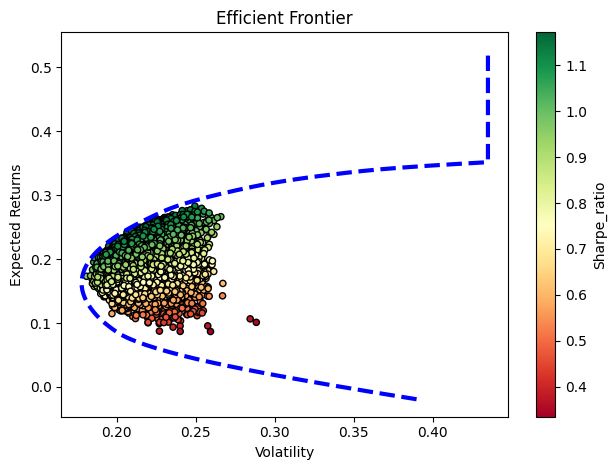

In [ ]:
fig, ax = plt.subplots()
portfolio_results.plot(kind = 'scatter',
                       x = 'volatility',
                       y = 'returns',
                       c = 'Sharpe_ratio',
                       cmap='RdYlGn', edgecolors='black',
                       ax = ax)
ax.plot(volatility_range, returns_range, 'b--', linewidth = 3) # b-- means blue line with line style --
ax.set(xlabel = 'Volatility',
       ylabel = 'Expected Returns',
       title = 'Efficient Frontier')
plt.tight_layout()
plt.show()

In [ ]:
min_vol = np.argmin(volatility_range) #Identifying index number or position of the minimum variance portfolio
min_vol_portfolio_return = returns_range[min_vol] #Return corresponding to minimum variance
min_vol_portoflio_volatility = efficient_portfolios[min_vol]['fun'] #the minimum variance in the efficient frontier

min_vol_portf = {'Return': min_vol_portfolio_return,
                 'Volatility': min_vol_portoflio_volatility,
                 'Sharpe_ratio': (min_vol_portfolio_return/min_vol_portoflio_volatility)
    }

In [ ]:
for x, y in zip(companies, efficient_portfolios[min_vol]['x']):
    print(f'{x}: {100*y:.2f}% ', end="", flush=True)

PARA: 9.72% NWSA: 0.83% TMUS: 3.93% NFLX: 1.19% META: 9.20% TTWO: 0.00% LYV: 42.75% TKO: 5.36% CHTR: 15.19% T: 11.84% 

In [ ]:
weights_df = pd.DataFrame.from_dict(dict(zip(companies, efficient_portfolios[min_vol]['x'])),
 orient='index',
 columns=['Weight'])

In [ ]:
weights_df

,Weight
PARA,9.715367e-02
NWSA,8.272854e-03
TMUS,3.927934e-02
NFLX,1.187783e-02
META,9.204531e-02
TTWO,4.330032e-18
LYV,4.274963e-01
TKO,5.360178e-02
CHTR,1.518761e-01
T,1.183968e-01


In [ ]:
sp

,symbol,security,gics_sector,gics_sub-industry,headquarters_location,date_added,cik,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [ ]:
companie_names = [row['security'] for index, row in sp.iterrows() if row['symbol'] in companies]

In [ ]:
# prompt: put companies and companies_names into the same dataframe but make sure they match (META goes with Met Platforms, etc)

import pandas as pd
# Create a dictionary to map tickers to company names
company_name_mapping = dict(zip(sp['symbol'], sp['security']))

# Create a list to store the company names corresponding to the tickers in the 'companies' list
companies_names = [company_name_mapping.get(ticker) for ticker in companies]

# Create a DataFrame with 'companies' and 'companies_names'
companies_df = pd.DataFrame({'companies': companies, 'companies_names': companies_names})

# Print the DataFrame
companies_df


,companies,companies_names
0,PARA,Paramount Global
1,NWSA,News Corp (Class A)
2,TMUS,T-Mobile US
3,NFLX,Netflix
4,META,Meta Platforms
5,TTWO,Take-Two Interactive
6,LYV,Live Nation Entertainment
7,TKO,TKO Group Holdings
8,CHTR,Charter Communications
9,T,AT&T


In [ ]:
companie_names

['AT&T',
 'Charter Communications',
 'Live Nation Entertainment',
 'Meta Platforms',
 'Netflix',
 'News Corp (Class A)',
 'Paramount Global',
 'T-Mobile US',
 'Take-Two Interactive',
 'TKO Group Holdings']

In [ ]:
initial_columns = returns.columns
aligned_weights = weights_df['Weight'].reindex(initial_columns, fill_value=0)


In [ ]:
returns['portfolio_returns'] = (returns * aligned_weights).sum(axis=1)

In [ ]:
def calculate_var(weights, avg_returns, cov_matrix, confidence_level=0.95, num_simulations=10000):
 portfolio_returns = np.sum(avg_returns * weights)
 portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

 simulated_returns = np.random.normal(portfolio_returns, portfolio_volatility, num_simulations)
 var = np.percentile(simulated_returns, (1 - confidence_level) * 100)

 return -var # Negative VaR for minimization

In [ ]:
def generate_efficient_frontier_var(avg_returns, cov_matrix, returns_range, confidence_level=0.95,
num_simulations=10000):

 efficient_portfolios_var = []
 n_tickers = len(avg_returns)
 inputs = (avg_returns, cov_matrix, confidence_level, num_simulations)
 bounds = tuple((0, 1) for ticker in range(n_tickers))
 initial_input = n_tickers * [1. / n_tickers]

 for ret in returns_range:
    constraints = (
 {'type': 'eq',
 'fun': lambda x: generate_portfolio_returns(x, avg_returns) - ret},
 {'type': 'eq',
 'fun': lambda x: np.sum(x) - 1}
 )

    efficient_portfolio_var = sco.minimize(
    lambda x: -calculate_var(x, *inputs), # Maximize VaR by minimizing negative VaR
    initial_input,
    method='SLSQP',
    constraints=constraints,
    bounds=bounds
    )

    efficient_portfolios_var.append(efficient_portfolio_var)
 return efficient_portfolios_var






In [ ]:
efficient_portfolios_var = generate_efficient_frontier_var(avg_returns, cov_matrix, returns_range,
confidence_level=0.97, num_simulations=10000)

In [ ]:
efficient_portfolios_var

[ message: Positive directional derivative for linesearch
  success: False
   status: 8
      fun: -0.8187385584257512
        x: [ 1.127e-07  2.760e-09  3.094e-08  5.148e-08  1.156e-01
             9.287e-01  2.498e-02  4.093e-01  1.690e-09  1.950e-01]
      nit: 67
      jac: [-1.645e+05  6.856e+05  3.498e+05  5.669e+05  1.016e+06
             3.638e+05  1.998e+06  1.410e+06  2.608e+06  3.921e+05]
     nfev: 1303
     njev: 63,
  message: Positive directional derivative for linesearch
  success: False
   status: 8
      fun: -0.19341563083990757
        x: [ 1.000e-01  1.000e-01  1.000e-01  1.000e-01  1.000e-01
             1.000e-01  1.000e-01  1.000e-01  1.000e-01  1.000e-01]
      nit: 5
      jac: [-4.043e+04 -1.940e+05 -2.067e+05  8.695e+04  2.959e+05
            -1.374e+04 -2.814e+05  1.544e+05  1.118e+05  1.502e+05]
     nfev: 11
     njev: 1,
  message: Positive directional derivative for linesearch
  success: False
   status: 8
      fun: -0.8383601484157102
        x: [ 4.0

In [ ]:
results_df_var = pd.DataFrame(columns=['Return', 'Portfolio Return', 'Value at Risk'] + list(companies))


In [ ]:
for i, efficient_portfolio_var in enumerate(efficient_portfolios_var):
 portfolio_weights = efficient_portfolio_var['x']
 portfolio_return = generate_portfolio_returns(portfolio_weights, avg_returns)
 portfolio_var = efficient_portfolio_var['fun'] # VaR is now positive

 row_data = [returns_range[i], portfolio_return, portfolio_var] + list(portfolio_weights)
 results_df_var.loc[i] = row_data

In [ ]:
results_df_var

,Return,Portfolio Return,Value at Risk,PARA,NWSA,TMUS,NFLX,META,TTWO,LYV,TKO,CHTR,T
0,-0.019298,0.155428,-0.818739,1.126702e-07,2.759887e-09,3.094323e-08,5.148148e-08,0.115609,0.928746,2.498162e-02,4.093471e-01,1.689795e-09,1.949921e-01
1,-0.016550,0.193809,-0.193416,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,0.100000,0.100000,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01
2,-0.013801,0.046999,-0.838360,4.000000e-10,3.000000e-10,5.733743e-02,1.653039e-01,0.032674,0.987404,4.000000e-10,4.000000e-10,3.794875e-02,3.000000e-10
3,-0.011053,0.033897,-0.752392,4.917406e-10,7.586652e-02,2.000000e-10,1.000000e-10,0.070660,0.862065,3.190452e-02,4.917406e-10,1.900870e-10,1.454773e-01
4,-0.008304,0.193809,-0.194293,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,0.100000,0.100000,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.516672,0.193809,-0.201514,1.000002e-01,9.999998e-02,9.999998e-02,1.000002e-01,0.100000,0.100000,9.999998e-02,1.000002e-01,9.999998e-02,1.000001e-01
196,0.519420,0.193809,-0.197049,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,0.100000,0.100000,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01
197,0.522169,0.193809,-0.195487,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,0.100000,0.100000,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01
198,0.524917,0.193809,-0.201761,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,0.100000,0.100000,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01


In [ ]:
max_var = results_df_var.loc[results_df_var['Value at Risk'].idxmax()]

In [ ]:
max_var

,84
Return,0.211581
Portfolio Return,0.193809
Value at Risk,-0.189375
PARA,0.100000
NWSA,0.100000
TMUS,0.100000
NFLX,0.100000
META,0.100000
TTWO,0.100000
LYV,0.100000


In [ ]:
for x, y in zip(companies, max_var[3:]):
    print(f'{x}: {100*y:.2f}% ', end="", flush=True)

PARA: 10.00% NWSA: 10.00% TMUS: 10.00% NFLX: 10.00% META: 10.00% TTWO: 10.00% LYV: 10.00% TKO: 10.00% CHTR: 10.00% T: 10.00% 

In [ ]:
var_range = [x['fun'] for x in efficient_portfolios_var]
weights_df_var = pd.DataFrame.from_dict(dict(zip(companies,
 efficient_portfolios_var[np.argmax(var_range)]['x'])),
 orient='index', columns=['Weight'])

In [ ]:
weights_df_var

,Weight
PARA,0.1
NWSA,0.1
TMUS,0.1
NFLX,0.1
META,0.1
TTWO,0.1
LYV,0.1
TKO,0.1
CHTR,0.1
T,0.1


In [ ]:
aligned_weights_var = weights_df_var['Weight'].reindex(initial_columns, fill_value=0)


In [ ]:
aligned_weights_var

,Weight
Ticker,
CHTR,0.1
LYV,0.1
META,0.1
NFLX,0.1
NWSA,0.1
PARA,0.1
T,0.1
TKO,0.1
TMUS,0.1


In [ ]:
returns['portfolio_returns1'] = (returns * aligned_weights_var).sum(axis=1)
returns['portfolio_returns2'] = (returns * aligned_weights_var).sum(axis=1)

In [ ]:
mycrs = returns['portfolio_returns'].cumsum().apply(np.exp)
mycrs_var = returns['portfolio_returns1'].cumsum().apply(np.exp)
equal_weights = returns['portfolio_returns2'].cumsum().apply(np.exp)

Summary Statistics for EFA Portfolio:
count    2835.000000
mean        0.000725
std         0.015255
min        -0.139553
25%        -0.006541
50%         0.000914
75%         0.008244
max         0.126702
Name: portfolio_returns, dtype: float64

Summary Statistics for VAR Portfolio:
count    2835.000000
mean        0.000769
std         0.013037
min        -0.115737
25%        -0.005487
50%         0.001046
75%         0.007580
max         0.097853
Name: portfolio_returns1, dtype: float64

Summary Statistics for Equal Weight Portfolio:
count    2835.000000
mean        0.000769
std         0.013037
min        -0.115737
25%        -0.005487
50%         0.001046
75%         0.007580
max         0.097853
Name: portfolio_returns2, dtype: float64


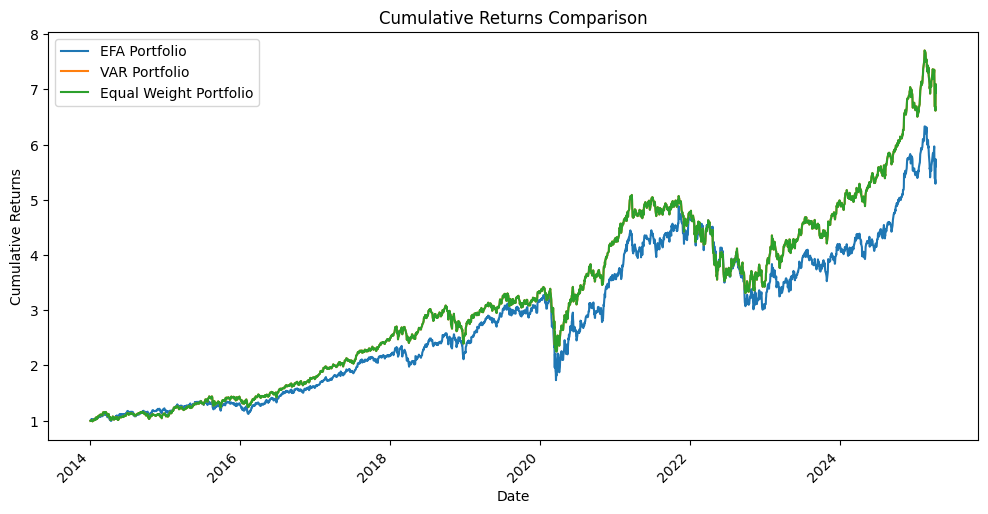

In [ ]:
# Create separate series for each portfolio's daily returns
ret_efa = returns['portfolio_returns']
ret_var = returns['portfolio_returns1']
ret_equal = returns['portfolio_returns2']

# Create summary statistics tables
summary_efa = ret_efa.describe()
summary_var = ret_var.describe()
summary_equal = ret_equal.describe()

# Display summary statistics
print("Summary Statistics for EFA Portfolio:")
print(summary_efa)
print("\nSummary Statistics for VAR Portfolio:")
print(summary_var)
print("\nSummary Statistics for Equal Weight Portfolio:")
print(summary_equal)

# Calculate cumulative returns
cumulative_efa = (1 + ret_efa).cumprod()
cumulative_var = (1 + ret_var).cumprod()
cumulative_equal = (1 + ret_equal).cumprod()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
cumulative_efa.plot(ax=ax, label='EFA Portfolio')
cumulative_var.plot(ax=ax, label='VAR Portfolio')
cumulative_equal.plot(ax=ax, label='Equal Weight Portfolio')

# Set plot properties
ax.set_title('Cumulative Returns Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Returns')
ax.legend()
plt.xticks(rotation=45)
plt.show()
